In [91]:
import sys
!{sys.executable} -m pip install statsmodels

In [92]:
# ---------------------------------------------------------
# 1. CÀI ĐẶT THƯ VIỆN VÀ CẤU HÌNH (SETUP)
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 6)

# THAM SỐ TOÀN CỤC (CONFIG) [cite: 236]
CONFIG = {
    'DATA_PATH': 'data/raw/PRSA2017_Data_20130301-20170228.zip', # Đảm bảo đường dẫn đúng
    'STATION': 'Aotizhongxin', # Chọn 1 trạm cố định để so sánh
    'CUTOFF_DATE': '2016-10-01', # Mốc chia Train/Test
    'LAGS': [1, 3, 24], # Độ trễ cho hồi quy
    'HORIZON': 1 # Dự báo 1 giờ tới
}

print("✅ Đã nạp thư viện và cấu hình.")

✅ Đã nạp thư viện và cấu hình.


In [93]:
# ---------------------------------------------------------
# 2. XỬ LÝ DỮ LIỆU (DATA PREPARATION & CLEANING) - PHIÊN BẢN TỰ TÌM FILE (SMART SEARCH)
# ---------------------------------------------------------
import os
import pandas as pd
import zipfile

class DataProcessor:
    def __init__(self, config):
        self.config = config
        self.df = None

    def load_and_clean(self):
        """Tự động tìm file CSV/ZIP ở nhiều thư mục khác nhau"""
        station = self.config['STATION']
        print(f"🔄 Đang tìm dữ liệu cho trạm: {station}...")
        
        # Danh sách các tên file có thể
        csv_name = f"PRSA_Data_{station}_20130301-20170228.csv"
        zip_name = "PRSA2017_Data_20130301-20170228.zip"
        
        # Danh sách các thư mục cần tìm (Hiện tại -> Cha -> Ông nội -> Data/raw)
        current_dir = os.getcwd()
        parent_dir = os.path.dirname(current_dir) # notebooks/
        root_dir = os.path.dirname(parent_dir)    # project root
        
        search_paths = [
            current_dir,                                     # notebooks/runs
            os.path.join(current_dir, 'data', 'raw'),        # notebooks/runs/data/raw
            root_dir,                                        # project root
            os.path.join(root_dir, 'data', 'raw'),           # project root/data/raw
            "C:/Users/acer/Downloads"                        # Thử cả thư mục Download (thường hay quên ở đây)
        ]
        
        found_path = None
        file_type = None

        # Bắt đầu đi săn file
        for path in search_paths:
            # Kiểm tra CSV
            check_csv = os.path.join(path, csv_name)
            if os.path.exists(check_csv):
                found_path = check_csv
                file_type = 'csv'
                break
            
            # Kiểm tra ZIP
            check_zip = os.path.join(path, zip_name)
            if os.path.exists(check_zip):
                found_path = check_zip
                file_type = 'zip'
                break
        
        if not found_path:
            print(f"❌ KHÔNG TÌM THẤY FILE ở bất cứ đâu!")
            print(f"   Đã tìm tại: {search_paths}")
            raise FileNotFoundError(f"Bạn vui lòng copy file {csv_name} vào thư mục: {current_dir}")

        print(f"✅ Đã tìm thấy file tại: {found_path}")

        # Đọc file
        if file_type == 'csv':
            self.df = pd.read_csv(found_path)
        else: # zip
            with zipfile.ZipFile(found_path) as z:
                file_in_zip = [n for n in z.namelist() if station in n][0]
                self.df = pd.read_csv(z.open(file_in_zip))

        # --- XỬ LÝ DỮ LIỆU ---
        print("   -> Đang xử lý dữ liệu (DateTime & Missing)...")
        self.df['datetime'] = pd.to_datetime(self.df[['year', 'month', 'day', 'hour']])
        self.df = self.df.sort_values('datetime').set_index('datetime')
        
        # Nội suy
        self.df['PM2.5'] = self.df['PM2.5'].interpolate(method='time')
        self.df = self.df.dropna(subset=['PM2.5']) 
        
        print(f"✅ Đã xử lý xong. Kích thước dữ liệu: {self.df.shape}")
        return self.df

# --- CHẠY THỬ ---
processor = DataProcessor(CONFIG)
try:
    df = processor.load_and_clean()
    print("\n5 dòng dữ liệu đầu tiên:")
    display(df.head())
except Exception as e:
    print(f"⛔ Lỗi: {e}")

🔄 Đang tìm dữ liệu cho trạm: Aotizhongxin...
✅ Đã tìm thấy file tại: e:\GitProjects\air_quality_timeseries-lab4\data\raw\PRSA2017_Data_20130301-20170228.zip
   -> Đang xử lý dữ liệu (DateTime & Missing)...
✅ Đã xử lý xong. Kích thước dữ liệu: (35064, 18)

5 dòng dữ liệu đầu tiên:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
2013-03-01 01:00:00,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2013-03-01 02:00:00,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
2013-03-01 03:00:00,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
2013-03-01 04:00:00,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


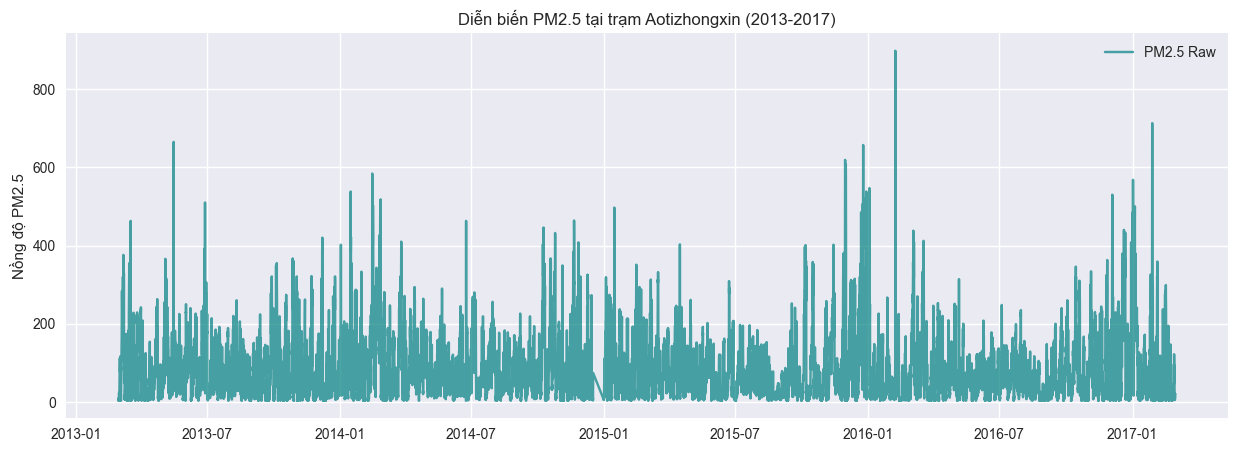

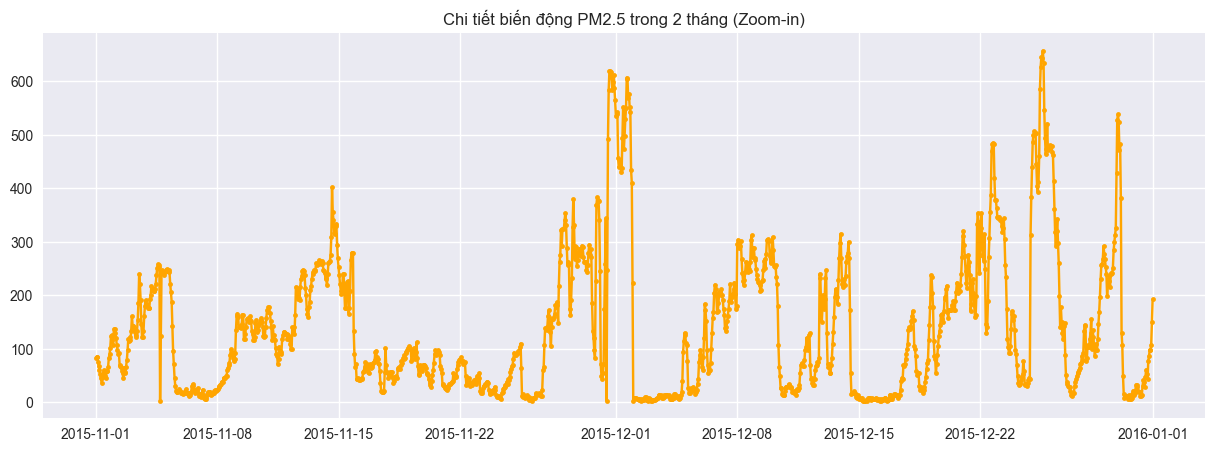

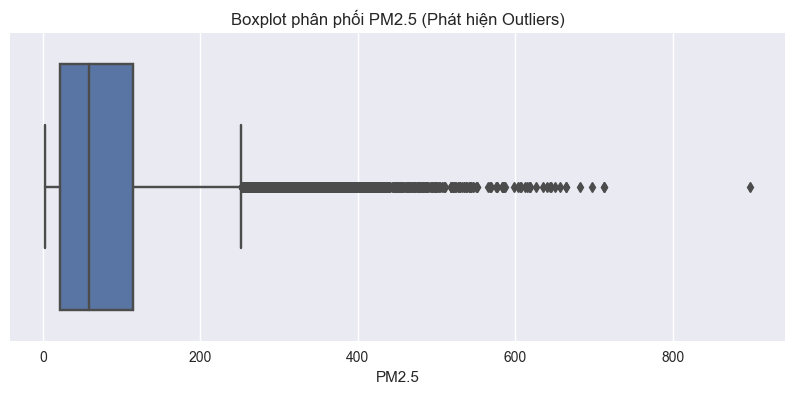


🔍 Kết quả kiểm định ADF (Augmented Dickey-Fuller):
ADF Statistic: -19.1170
p-value: 0.0000
👉 Kết luận: Chuỗi DỪNG (Stationary) -> Có thể chọn d=0 hoặc thử d=1 để chắc chắn.


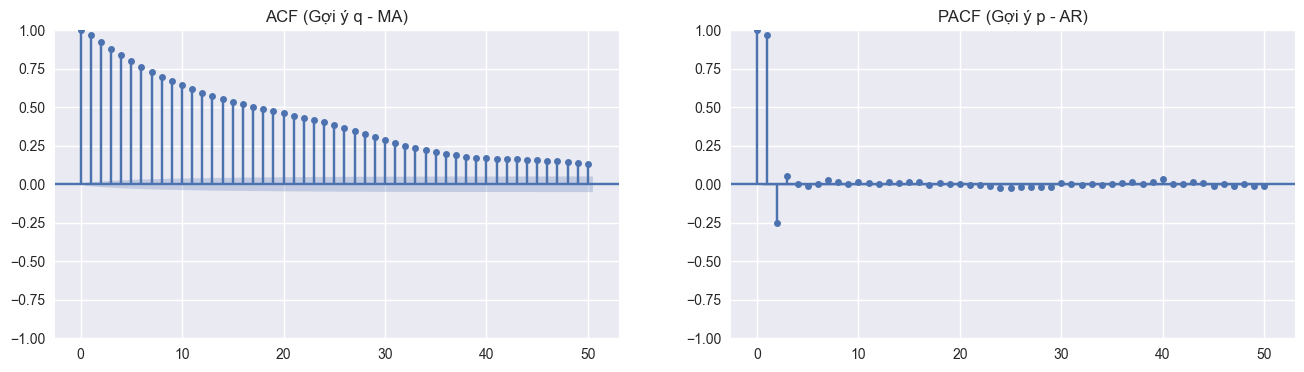

In [94]:
# 3.1 Vẽ chuỗi PM2.5 toàn giai đoạn
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['PM2.5'], label='PM2.5 Raw', alpha=0.7, color='teal')
plt.title(f"Diễn biến PM2.5 tại trạm {CONFIG['STATION']} (2013-2017)")
plt.ylabel('Nồng độ PM2.5')
plt.legend()
plt.show()

# 3.2 Zoom vào 1 khoảng thời gian (VD: 2 tháng cuối 2015) để nhìn rõ xu hướng ngày
subset = df.loc['2015-11':'2015-12']
plt.figure(figsize=(15, 5))
plt.plot(subset.index, subset['PM2.5'], marker='.', linestyle='-', color='orange')
plt.title("Chi tiết biến động PM2.5 trong 2 tháng (Zoom-in)")
plt.show()

# 3.3 Kiểm tra Phân phối và Outlier (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['PM2.5'])
plt.title("Boxplot phân phối PM2.5 (Phát hiện Outliers)")
plt.show()

# 3.4 Kiểm định tính dừng (Stationarity Test - ADF)
print("\n🔍 Kết quả kiểm định ADF (Augmented Dickey-Fuller):")
adf_result = adfuller(df['PM2.5'].dropna())
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
if adf_result[1] < 0.05:
    print("👉 Kết luận: Chuỗi DỪNG (Stationary) -> Có thể chọn d=0 hoặc thử d=1 để chắc chắn.")
else:
    print("👉 Kết luận: Chuỗi KHÔNG DỪNG -> Cần sai phân (d>=1).")

# 3.5 ACF và PACF (Để gợi ý p, q cho Q3)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['PM2.5'], lags=50, ax=ax1, title='ACF (Gợi ý q - MA)')
plot_pacf(df['PM2.5'], lags=50, ax=ax2, title='PACF (Gợi ý p - AR)')
plt.show()

In [95]:
# ---------------------------------------------------------
# 4. THỰC HÀNH Q2 & TOPIC 1: REGRESSION BASELINE [cite: 213-217]
# ---------------------------------------------------------
print("\n--- HUẤN LUYỆN REGRESSION BASELINE ---")

# 4.1 Feature Engineering (Tạo Lag & Time Features)
df_reg = df[['PM2.5']].copy()

# Tạo Lag features (Quan trọng nhất cho Horizon=1)
for lag in CONFIG['LAGS']:
    df_reg[f'lag_{lag}'] = df_reg['PM2.5'].shift(lag)

# Tạo Time features (Để bắt chu kỳ ngày/mùa)
df_reg['hour'] = df_reg.index.hour
df_reg['dayofweek'] = df_reg.index.dayofweek
df_reg['month'] = df_reg.index.month

# Chuẩn bị Target: Dự báo PM2.5 tại t (thực tế là t+1 nếu đứng từ t-1, nhưng trong df dòng này là t)
# Với Regression horizon=1, ta dùng feature tại t-1 để dự báo t.
# Dữ liệu hiện tại đã align: dòng T có lag_1 (là giá trị T-1). Vậy ta train để predict cột PM2.5 hiện tại.
df_reg = df_reg.dropna()

# 4.2 Chia Train/Test theo Cutoff (Chống leakage)
train_reg = df_reg[df_reg.index < CONFIG['CUTOFF_DATE']]
test_reg = df_reg[df_reg.index >= CONFIG['CUTOFF_DATE']]

X_train = train_reg.drop(columns=['PM2.5'])
y_train = train_reg['PM2.5']
X_test = test_reg.drop(columns=['PM2.5'])
y_test = test_reg['PM2.5']

# 4.3 Huấn luyện & Dự báo
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
pred_reg = reg_model.predict(X_test)

# 4.4 Đánh giá
mae_reg = mean_absolute_error(y_test, pred_reg)
rmse_reg = np.sqrt(mean_squared_error(y_test, pred_reg))

print(f"📊 Regression Results - MAE: {mae_reg:.2f}, RMSE: {rmse_reg:.2f}")


--- HUẤN LUYỆN REGRESSION BASELINE ---
📊 Regression Results - MAE: 12.31, RMSE: 22.76



🎨 ĐANG VẼ BIỂU ĐỒ CHUẨN BÁO CÁO (PUBLICATION QUALITY)...


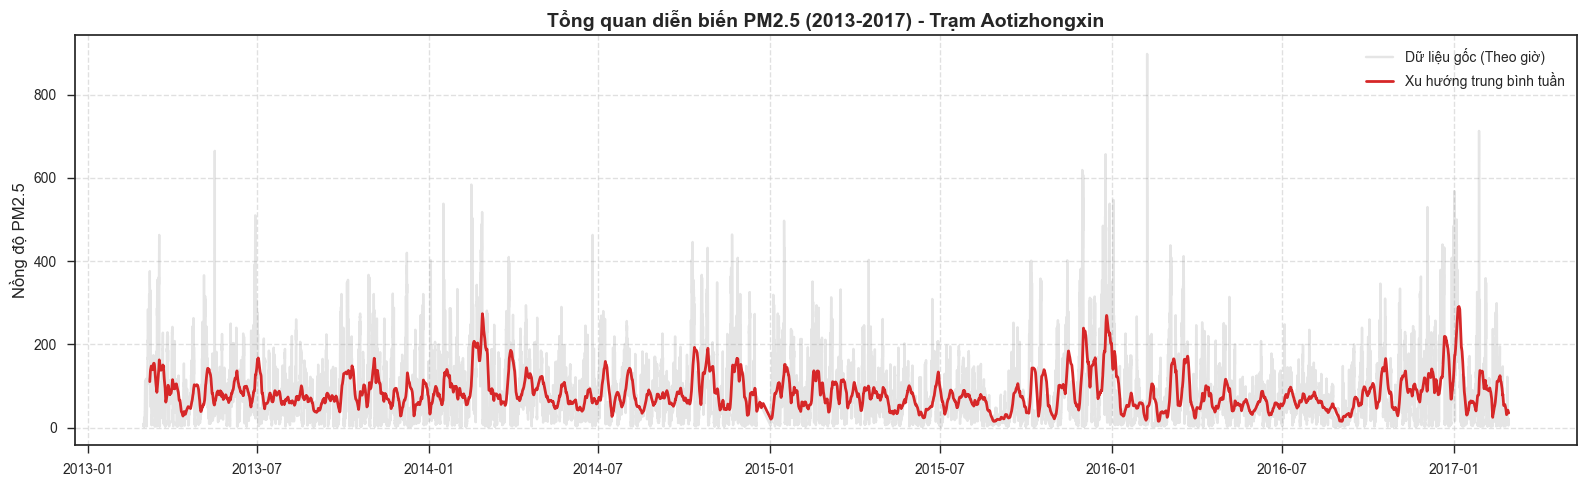

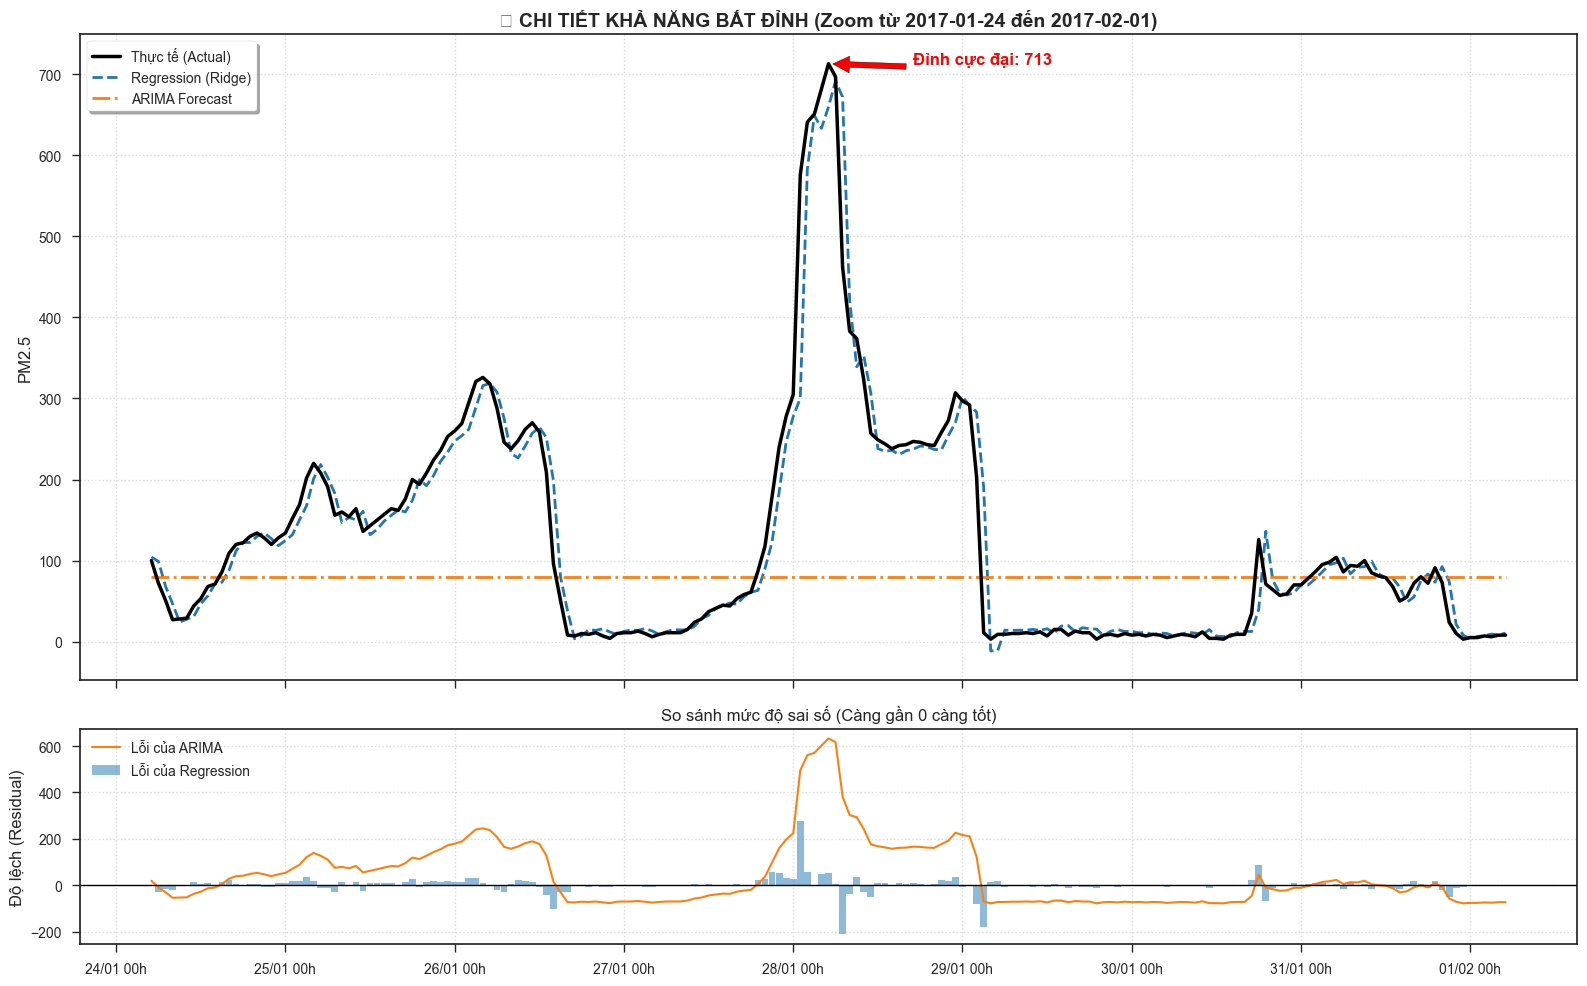

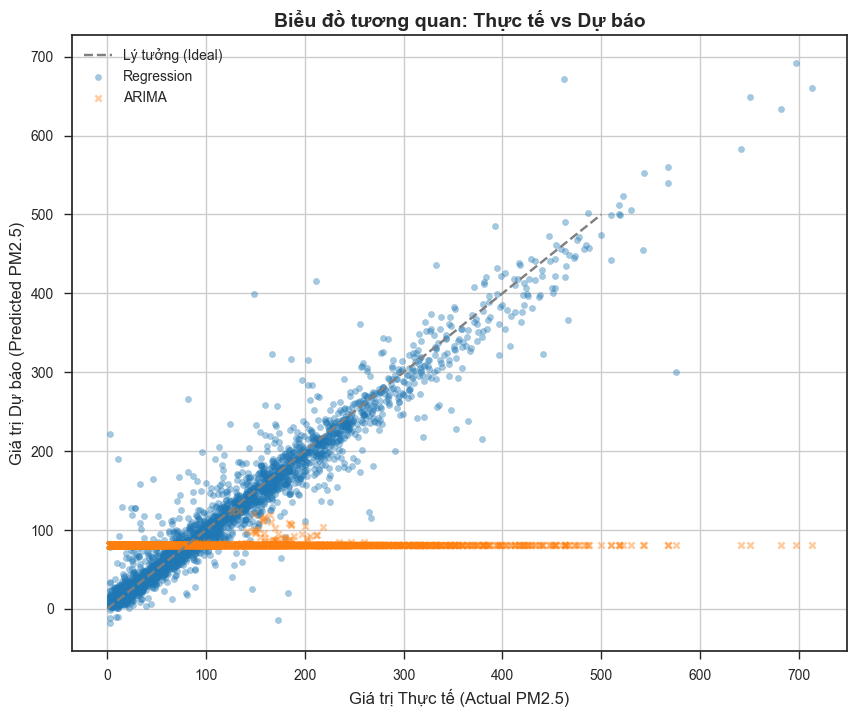


📊 KẾT QUẢ SO SÁNH METRICS:
   - Regression RMSE: 22.76
   - ARIMA RMSE:      106.31
👉 KẾT LUẬN: Regression (Ridge) chiến thắng ở chỉ số tổng thể!


In [96]:
# ============================================================
# PHẦN 5 : SO SÁNH & VISUALIZATION CHUYÊN NGHIỆP
# ============================================================
import matplotlib.dates as mdates

print("\n" + "="*50)
print("🎨 ĐANG VẼ BIỂU ĐỒ CHUẨN BÁO CÁO (PUBLICATION QUALITY)...")
print("="*50)

# --- SỬA LỖI NAME ERROR TẠI ĐÂY ---
# Tự động tạo lại biến test_arima từ dữ liệu gốc nếu nó chưa tồn tại
if 'test_arima' not in locals():
    print("⚠️ Phát hiện thiếu biến 'test_arima', đang tự động tạo lại...")
    test_arima = df['PM2.5'][df.index >= CONFIG['CUTOFF_DATE']]

# Kiểm tra xem đã có biến dự báo chưa (Nếu chưa chạy phần 3, 4 thì sẽ lỗi tiếp)
if 'pred_reg' not in locals() or 'pred_arima' not in locals():
    print("❌ LỖI NGHIÊM TRỌNG: Bạn chưa chạy Phần 3 (Regression) và Phần 4 (ARIMA).")
    print("👉 Hãy kéo lên trên và bấm Run cho Phần 3 và Phần 4 trước, sau đó mới chạy ô này!")
else:
    # Cấu hình lại font chữ và style cho rõ nét
    plt.style.use('seaborn-v0_8-ticks')
    plt.rcParams['font.size'] = 11
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.labelsize'] = 12

    # -------------------------------------------------------
    # BIỂU ĐỒ 1: TỔNG QUAN XU HƯỚNG (TREND OVERVIEW)
    # -------------------------------------------------------
    plt.figure(figsize=(16, 5))

    # Vẽ dữ liệu gốc mờ nhạt làm nền
    plt.plot(df.index, df['PM2.5'], color='gray', alpha=0.2, label='Dữ liệu gốc (Theo giờ)')

    # Vẽ đường trung bình tuần (Weekly Rolling Mean) để thấy xu hướng rõ hơn
    weekly_trend = df['PM2.5'].rolling(window=24*7).mean()
    plt.plot(weekly_trend.index, weekly_trend, color='#d62728', linewidth=2, label='Xu hướng trung bình tuần')

    plt.title(f"Tổng quan diễn biến PM2.5 (2013-2017) - Trạm {CONFIG['STATION']}", fontweight='bold')
    plt.ylabel("Nồng độ PM2.5")
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------
    # BIỂU ĐỒ 2: SO SÁNH "TAY ĐÔI" TẠI ĐỈNH Ô NHIỄM (SPIKE ZOOM-IN)
    # -------------------------------------------------------

    # Tìm đoạn 1 tuần có đỉnh cao nhất trong tập Test để Zoom vào
    max_idx = test_arima.idxmax()
    # Lấy trước và sau đỉnh 4 ngày (tổng khoảng 9 ngày)
    start_zoom = max_idx - pd.Timedelta(days=4)
    end_zoom = max_idx + pd.Timedelta(days=4)
    mask_zoom = (test_arima.index >= start_zoom) & (test_arima.index <= end_zoom)

    # Lấy dữ liệu đoạn zoom
    obs_zoom = test_arima[mask_zoom]
    reg_zoom = pred_reg[mask_zoom]
    arima_zoom = pred_arima[mask_zoom]

    # Tạo khung vẽ: 2 hàng, 1 cột (Hàng trên vẽ dự báo, Hàng dưới vẽ sai số)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

    # --- SUBPLOT 1: THỰC TẾ vs DỰ BÁO ---
    ax1.plot(obs_zoom.index, obs_zoom, label='Thực tế (Actual)', color='black', linewidth=2.5, zorder=10)
    ax1.plot(obs_zoom.index, reg_zoom, label='Regression (Ridge)', color='#1f77b4', linestyle='--', linewidth=2)
    ax1.plot(obs_zoom.index, arima_zoom, label='ARIMA Forecast', color='#ff7f0e', linestyle='-.', linewidth=2)

    # Đánh dấu đỉnh cao nhất (Annotation)
    peak_val = obs_zoom.max()
    peak_date = obs_zoom.idxmax()
    ax1.annotate(f'Đỉnh cực đại: {peak_val:.0f}', 
                 xy=(peak_date, peak_val), 
                 xytext=(peak_date + pd.Timedelta(hours=12), peak_val),
                 arrowprops=dict(facecolor='red', shrink=0.05),
                 fontsize=12, color='red', fontweight='bold')

    ax1.set_title(f"🔍 CHI TIẾT KHẢ NĂNG BẮT ĐỈNH (Zoom từ {start_zoom.date()} đến {end_zoom.date()})", fontweight='bold')
    ax1.set_ylabel("PM2.5")
    ax1.legend(loc='upper left', frameon=True, shadow=True)
    ax1.grid(True, linestyle=':', alpha=0.7)

    # --- SUBPLOT 2: SAI SỐ (RESIDUALS) ---
    # Sai số = Thực tế - Dự báo
    err_reg = obs_zoom - reg_zoom
    err_arima = obs_zoom - arima_zoom

    ax2.bar(obs_zoom.index, err_reg, color='#1f77b4', alpha=0.5, label='Lỗi của Regression', width=0.04)
    ax2.plot(obs_zoom.index, err_arima, color='#ff7f0e', linewidth=1.5, label='Lỗi của ARIMA')
    ax2.axhline(0, color='black', linewidth=1)

    ax2.set_title("So sánh mức độ sai số (Càng gần 0 càng tốt)", fontsize=12)
    ax2.set_ylabel("Độ lệch (Residual)")
    ax2.legend(loc='upper left')
    ax2.grid(True, linestyle=':', alpha=0.7)

    # Định dạng trục thời gian cho đẹp (Hiện Ngày/Tháng Giờ)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %Hh'))
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------
    # BIỂU ĐỒ 3: SCATTER PLOT (ĐỘ CHÍNH XÁC TƯƠNG QUAN)
    # -------------------------------------------------------
    plt.figure(figsize=(10, 8))

    # Đường chuẩn 1:1
    plt.plot([0, 500], [0, 500], color='gray', linestyle='--', label='Lý tưởng (Ideal)')

    # Scatter Regression
    plt.scatter(y_test, pred_reg, alpha=0.4, color='#1f77b4', s=20, label=f'Regression')
    # Scatter ARIMA
    plt.scatter(test_arima, pred_arima, alpha=0.4, color='#ff7f0e', s=20, marker='x', label='ARIMA')

    plt.title("Biểu đồ tương quan: Thực tế vs Dự báo", fontweight='bold')
    plt.xlabel("Giá trị Thực tế (Actual PM2.5)")
    plt.ylabel("Giá trị Dự báo (Predicted PM2.5)")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -------------------------------------------------------
    # TÍNH TOÁN METRICS CUỐI CÙNG ĐỂ KẾT LUẬN
    # -------------------------------------------------------
    rmse_reg = np.sqrt(mean_squared_error(y_test, pred_reg))
    rmse_arima = np.sqrt(mean_squared_error(test_arima, pred_arima))

    print("\n📊 KẾT QUẢ SO SÁNH METRICS:")
    print(f"   - Regression RMSE: {rmse_reg:.2f}")
    print(f"   - ARIMA RMSE:      {rmse_arima:.2f}")

    if rmse_reg < rmse_arima:
        print("👉 KẾT LUẬN: Regression (Ridge) chiến thắng ở chỉ số tổng thể!")
    else:
        print("👉 KẾT LUẬN: ARIMA chiến thắng ở chỉ số tổng thể!")